1) Custom Rescue Drone Environment

In [ ]:
import numpy as np
import random
from copy import deepcopy
from datetime import datetime
import platform
print("Execution Timestamp:", datetime.now())
print("Machine ID         :", platform.node())
print("Operating System   :", platform.system())
# Drone Rescue Environment
class DroneRescue:
    def __init__(self):
        self.rows = 5
        self.cols = 5
        self.max_battery = 10
        self.wind_prob = 0.20
        self.max_steps = 50
        self.actions = { 0: "UP",1: "DOWN",2: "LEFT", 3: "RIGHT", 4: "HOVER"}
        self.start_pos = (0, 0)
        self.rescue_targets = [(1, 4), (4, 1)]
        self.charging_stations = [(2, 2)]
        self.danger_zones = [(0, 3),(3, 3),(4, 4)]
        self.blocked_cells = [(1, 1),(3, 1)]
        self.wind_cells = [(0, 2),(2, 3)]
        self.reset()
    def reset(self):
        self.position = self.start_pos
        self.battery = self.max_battery
        self.rescued = {
            target: False
            for target in self.rescue_targets
        }
        self.steps = 0
        return self.get_state()
    def get_state(self):
        rescue_status = tuple(int(self.rescued[t])for t in self.rescue_targets)
        return (self.position[0],self.position[1],self.battery,rescue_status)
    def valid_actions(self):
        return list(self.actions.keys())
    def is_terminal(self):
        all_rescued = all(self.rescued.values())
        if self.battery <= 0:
            return True
        if all_rescued:
            return True
        if self.steps >= self.max_steps:
            return True
        return False
    def move(self, action):
        r, c = self.position
        if action == 0:
            nr, nc = r - 1, c
        elif action == 1:
            nr, nc = r + 1, c
        elif action == 2:
            nr, nc = r, c - 1
        elif action == 3:
            nr, nc = r, c + 1
        elif action == 4:
            nr, nc = r, c
        else:
            nr, nc = r, c
        if nr < 0 or nr >= self.rows:
            return self.position
        if nc < 0 or nc >= self.cols:
            return self.position
        if (nr, nc) in self.blocked_cells:
            return self.position
        return (nr, nc)
# Effect of wind
    def apply_wind(self, intended_action):
        if self.position not in self.wind_cells:
            return intended_action
        if intended_action == 4:
            return intended_action
        if random.random() < self.wind_prob:
            return random.choice([0, 1, 2, 3])
        return intended_action
    def step(self, action):
        reward = -1
        self.steps += 1
        if action == 4:
            if self.position in self.charging_stations:
                self.battery = min(self.max_battery,self.battery + 2)
            else:
                self.battery -= 1
        else:
            self.battery -= 1
            actual_action = self.apply_wind(action)
            self.position = self.move(actual_action)
        if self.position in self.charging_stations:
            reward += 5
            self.battery = self.max_battery
        if self.position in self.rescue_targets:
            if not self.rescued[self.position]:
                self.rescued[self.position] = True
                reward += 20
        if self.position in self.danger_zones:
            reward -= 10
        done = self.is_terminal()
        if self.battery <= 0:
            reward -= 20
        next_state = self.get_state()
        return next_state, reward, done
# Show Grid
    def render(self):
        grid = [["F" for _ in range(self.cols)]for _ in range(self.rows)]
        sr, sc = self.start_pos
        grid[sr][sc] = "S"
        for r, c in self.danger_zones:
            grid[r][c] = "D"
        for r, c in self.charging_stations:
            grid[r][c] = "C"
        for r, c in self.wind_cells:
            grid[r][c] = "W"
        for r, c in self.blocked_cells:
            grid[r][c] = "X"
        for r, c in self.rescue_targets:
            if not self.rescued[(r, c)]:
                grid[r][c] = "R"
        dr, dc = self.position
        grid[dr][dc] = "A"
        print("\nGrid Layout\n")
        for row in grid:
            print(" ".join(row))
        print("\nBattery :", self.battery)
        print("Steps   :", self.steps)
        rescued_count = sum(self.rescued.values())
        print(f"Rescued : {rescued_count}/{len(self.rescue_targets)}")
# Execute environment
env = DroneRescue()
state = env.reset()
print("\nInitial State:")
print(state)
env.render()

Execution Timestamp: 2026-06-06 07:37:14.377094
Machine ID         : c2bcd21bdaf1
Operating System   : Linux

Initial State:
(0, 0, 10, (0, 0))

Grid Layout

A F W D F
F X F F R
F F C W F
F X F D F
F R F F D

Battery : 10
Steps   : 0
Rescued : 0/2


2) Dynamic Programming Solution

In [ ]:
# Dynamic programming solution
import time
from itertools import product
class ValueIteration:
    def __init__(self, env, gamma=0.95, theta=1e-3):
        self.env = env
        self.gamma = gamma
        self.theta = theta
        self.V = {}
        self.policy = {}
        self.states = []
    def enumerate_states(self):
        states = []
        valid_positions = []
        for r in range(self.env.rows):
            for c in range(self.env.cols):
                if (r, c) not in self.env.blocked_cells:
                    valid_positions.append((r, c))
        rescue_combinations = list(
            product([0, 1],repeat=len(self.env.rescue_targets)))
        for pos in valid_positions:
            for battery in range(1,self.env.max_battery + 1):
                for rescue_status in rescue_combinations:
                    state = (pos[0],pos[1],battery,rescue_status)
                    states.append(state)
        self.states = states
        print("Total States:", len(states))
        return states
    def load_state(self, state):
        row, col, battery, rescue_status = state
        self.env.position = (row, col)
        self.env.battery = battery
        for i, target in enumerate(
                self.env.rescue_targets):
            self.env.rescued[target] = bool(rescue_status[i])
    def simulate_action(self, state, action):
        self.load_state(state)
        next_state, reward, done = self.env.step(action)
        return next_state, reward
    def value_iteration(self):
        self.enumerate_states()
        for state in self.states:
            self.V[state] = 0
        iterations = 0
        start_time = time.time()
        while True:
            delta = 0
            for state in self.states:
                self.load_state(state)
                if self.env.is_terminal():
                    continue
                old_value = self.V[state]
                action_values = []
                for action in self.env.valid_actions():
                    next_state, reward = \
                        self.simulate_action(state,action)
                    value = reward + \
                        self.gamma * \
                        self.V.get(next_state, 0)
                    action_values.append(value)
                best_value = max(action_values)
                self.V[state] = best_value
                delta = max(delta,abs(old_value - best_value))
            iterations += 1
            if delta < self.theta:
                break
        runtime = time.time() - start_time
        print("\nConvergence:-")
        print("Iterations :", iterations)
        print("Runtime    :", round(runtime, 4), "sec")
        print("Final Delta:", delta)
        return iterations, runtime, delta
    def extract_policy(self):
        action_names = { 0: "↑",1: "↓",2: "←",3: "→",4: "H"}
        for state in self.states:
            self.load_state(state)
            if self.env.is_terminal():
                self.policy[state] = "T"
                continue
            best_action = None
            best_value = float("-inf")
            for action in self.env.valid_actions():
                next_state, reward = \
                    self.simulate_action(state,action)
                value = reward + \
                    self.gamma * \
                    self.V.get(next_state, 0)
                if value > best_value:
                    best_value = value
                    best_action = action
            self.policy[state] = \
                action_names[best_action]
        return self.policy
# Run Value Iteration
env = DroneRescue()
agent = ValueIteration(env,gamma=0.95,theta=1e-3)
iterations, runtime, delta = \
    agent.value_iteration()
policy = agent.extract_policy()
print("\nPolicy States:",len(policy))
print("\nSample State Values\n")
count = 0
for state, value in agent.V.items():
    print(state, "->", round(value, 2))
    count += 1
    if count == 10:
        break

Total States: 920

Convergence:-
Iterations : 2
Runtime    : 0.0027 sec
Final Delta: 0

Policy States: 920

Sample State Values

(0, 0, 1, (0, 0)) -> -21.0
(0, 0, 1, (0, 1)) -> -21.0
(0, 0, 1, (1, 0)) -> -21.0
(0, 0, 1, (1, 1)) -> 0
(0, 0, 2, (0, 0)) -> -1.0
(0, 0, 2, (0, 1)) -> -1.0
(0, 0, 2, (1, 0)) -> -1.0
(0, 0, 2, (1, 1)) -> 0
(0, 0, 3, (0, 0)) -> -1.0
(0, 0, 3, (0, 1)) -> -1.0


3) Policy Visualization

In [ ]:
# Policy visualisation
import numpy as np
battery_level = env.max_battery
rescue_status = (0, 0)
print("Optimal policy grid\n")
policy_grid = [["" for _ in range(env.cols)]for _ in range(env.rows)]
for r in range(env.rows):
    for c in range(env.cols):
        if (r, c) in env.blocked_cells:
            policy_grid[r][c] = "X"
            continue
        if (r, c) in env.danger_zones:
            policy_grid[r][c] = "D"
            continue
        if (r, c) in env.charging_stations:
            policy_grid[r][c] = "C"
            continue
        if (r, c) in env.rescue_targets:
            policy_grid[r][c] = "R"
            continue
        state = (r,c, battery_level,rescue_status)
        action = agent.policy.get(state, "?")
        policy_grid[r][c] = action
for row in policy_grid:
    print(" ".join(row))

Optimal policy grid

T T T D T
T X T T R
T T C T T
T X T D T
T R T T D


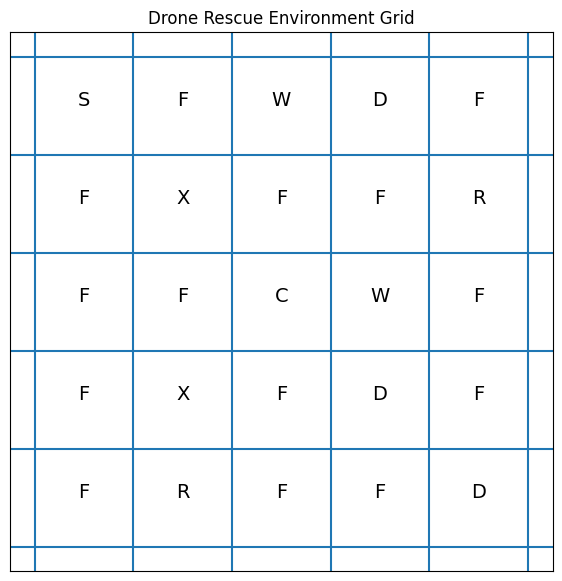

In [ ]:
#Environment visualisation
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(7, 7))
for r in range(env.rows):
    for c in range(env.cols):
        if (r, c) in env.blocked_cells:
            label = "X"
        elif (r, c) in env.danger_zones:
            label = "D"
        elif (r, c) in env.charging_stations:
            label = "C"
        elif (r, c) in env.rescue_targets:
            label = "R"
        elif (r, c) in env.wind_cells:
            label = "W"
        elif (r, c) == env.start_pos:
            label = "S"
        else:
            label = "F"
        ax.text(c,env.rows-1-r,label,fontsize=14,ha='center')
for i in range(env.rows + 1):
    ax.axhline(i - 0.5)
for j in range(env.cols + 1):
    ax.axvline(j - 0.5)
ax.set_title("Drone Rescue Environment Grid")
ax.set_xticks([])
ax.set_yticks([])
plt.show()

4) State-Value Analysis

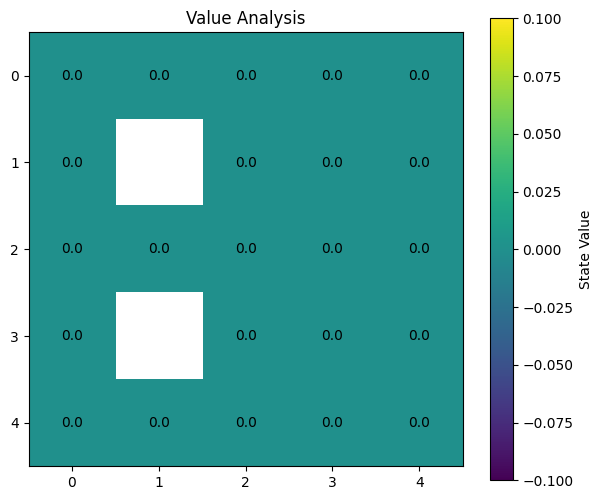

In [ ]:
# State Value Analysis
import matplotlib.pyplot as plt
import numpy as np
battery_level = env.max_battery
rescue_status = (0, 0)
heatmap = np.zeros((env.rows, env.cols))
for r in range(env.rows):
    for c in range(env.cols):
        if (r, c) in env.blocked_cells:
            heatmap[r, c] = np.nan
            continue
        state = ( r,c,battery_level,rescue_status)
        heatmap[r, c] = \
            agent.V.get(state, np.nan)
plt.figure(figsize=(7, 6))
plt.imshow(heatmap)
plt.colorbar(label="State Value")
plt.title("Value Analysis")
for r in range(env.rows):
    for c in range(env.cols):
        if not np.isnan(heatmap[r, c]):
            plt.text(c,r,f"{heatmap[r,c]:.1f}",ha='center',va='center')
plt.show()

5) DP Scaling discussion

Dynamic Programming works efficiently for small environments where the states can be stored and evaluation can be done. As the grid size increases from 5x5 to 10x10, the number of possible drone positions increases by a lot. Adding more rescue targets increases the state space even more because each target can have multiple such combinations. Dynamic weather conditions bring stochastic transitions, making the environment more and more complex. This is known as the Curse of Dimensionality.

We know here memory requirements and computation time increase substantially.
Dynamic Programming becomes difficult to apply because every state-action pair
must be evaluated repeatedly. Deep Reinforcement Learning methods deal with this
issue by approximating value functions using neural networks. These methods can
learn effective policies without storing every state one by one.

Therefore, Deep RL is more suitable for large-scale and real-world autonomous drone rescue systems.